## Baseline: Logistische Regression

In [1]:
# setup

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml    # lädt den Datensatz von OpenML

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer    # verarbeitet diverse Spalten vor
from sklearn.pipeline import Pipeline      # # Verbindet mehrere Verarbeitungsschritte zu einer Pipeline
from sklearn.impute import SimpleImputer   # Ersetzt fehlende Werte (NaN) durch einen festgelegten Wert
from sklearn.preprocessing import StandardScaler, OneHotEncoder   # standardisiert numerische Variablen + wandelt kategoriale Variablen in numerische 0/1-Spalten um
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score   # teilt die Daten für Cross-Validation in mehrere Folds auf + trainiert und evaluiert das Modell automatisch
from sklearn.metrics import roc_auc_score   # Berechnet den ROC-AUC-Wert 

RANDOM_STATE = 42

In [2]:
# daten laden

def load_porto_seguro() -> pd.DataFrame:
    """Lädt den Porto-Seguro-Datensatz von OpenML (target als int 0/1, fehlend = NaN)."""
    ds = fetch_openml(data_id=42742, as_frame=True, parser="auto")
    df = ds.frame.rename(columns={ds.target.name: "target"})
    df["target"] = df["target"].astype(int)
    return df

def build_meta(df: pd.DataFrame) -> pd.DataFrame:
    """Leitet Rolle, Skalenniveau und Gruppe jedes Features aus dem Namen ab."""
    rows = []
    for col in df.columns:
        role = "target" if col == "target" else ("id" if col == "id" else "input")
        if col in ("id", "target"):
            level = col
        elif col.endswith("bin"):
            level = "binary"
        elif col.endswith("cat"):
            level = "nominal"
        elif pd.api.types.is_numeric_dtype(df[col]):
            level = "interval" if (df[col].dropna() % 1 != 0).any() else "ordinal"
        else:
            level = "nominal"
        group = col.split("_")[1] if col.startswith("ps_") else "meta"
        rows.append({"varname": col, "role": role, "level": level, "group": group,
                     "dtype": str(df[col].dtype), "n_missing": int(df[col].isna().sum()),
                     "n_unique": int(df[col].nunique())})
    return pd.DataFrame(rows).set_index("varname")

def column_groups(meta: pd.DataFrame) -> dict:
    return {"bin": meta.index[meta.level == "binary"].tolist(),
            "cat": meta.index[meta.level == "nominal"].tolist(),
            "num": meta.index[meta.level.isin(["interval", "ordinal"])].tolist()}

# laden
train = load_porto_seguro()
meta  = build_meta(train)
cols  = column_groups(meta)
bin_cols, cat_cols, num_cols = cols["bin"], cols["cat"], cols["num"]
print(f"{len(bin_cols)} binär · {len(cat_cols)} kategorial · {len(num_cols)} numerisch")

17 binär · 14 kategorial · 26 numerisch


In [3]:
# Feature-Matrix und target trennen. Binär + numerisch als Zahlen, kategorial als Objekt (für OHE).

numeric_features = num_cols + bin_cols
categorical_features = cat_cols

X = train.drop(columns="target").copy()
X[numeric_features]     = X[numeric_features].apply(pd.to_numeric, errors="coerce")
X[categorical_features] = X[categorical_features].astype(object)
y = train["target"].astype(int)

# Normalisierter Gini (2 x AUC − 1)
def gini_normalized(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1

In [ ]:
# Numerisch: Median-Imputation (+ Missing-Indikator) und Standardisierung.
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale",  StandardScaler()),])

# Kategorial: fehlend -> eigene Kategorie "MISSING", dann One-Hot.
# min_frequency fasst seltene Kategorien zusammen -> robust bei ps_car_11_cat (~104 Werte).
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50)),])

pre = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),])

model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(
        solver="lbfgs", penalty="l2", C=1.0,
        class_weight="balanced",       # Klassenungleichgewicht ohne Oversampling
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),])

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

auc = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
gini = 2 * auc - 1

print("AUC je Fold:", np.round(auc, 4))
print(f"AUC : {auc.mean():.4f} ± {auc.std():.4f}")
print(f"Gini: {gini.mean():.4f} ± {gini.std():.4f}")

/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet

AUC je Fold: [0.6338 0.6281 0.6299 0.6328 0.6254]
AUC : 0.6300 ± 0.0031
Gini: 0.2600 ± 0.0062


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet

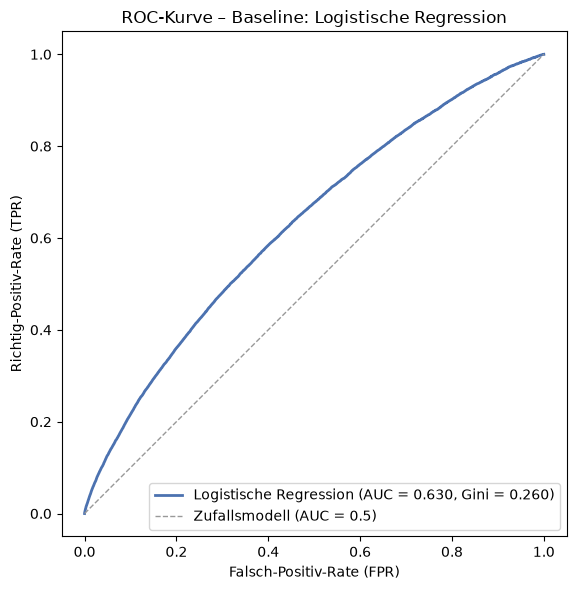

In [6]:


# Out-of-fold-Wahrscheinlichkeiten für die positive Klasse (kein Leakage).
# [:, 1] = Spalte der Klasse "1"; dieselbe skf wie bei der Kreuzvalidierung.
y_proba = cross_val_predict(model, X, y, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

# ROC-Kurve und Kennzahlen berechnen
fpr, tpr, _ = roc_curve(y, y_proba)
auc = roc_auc_score(y, y_proba)
gini = 2 * auc - 1

# plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#4C72B0", lw=2,
        label=f"Logistische Regression (AUC = {auc:.3f}, Gini = {gini:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="#999", lw=1, label="Zufallsmodell (AUC = 0.5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title("ROC-Kurve – Baseline: Logistische Regression")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()